In [3]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
mnist_test = datasets.MNIST(
    root="./data", train=False, download=False, transform=transform
)

# Stack images: result shape -> (N, 1, 28, 28)
X_train = torch.stack([mnist_train[i][0] for i in range(len(mnist_train))])  # -> (N,1,28,28)
# Labels: result shape -> (N,)
y_train = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])  # -> (N,)

device = "mps" if torch.backends.mps.is_available() else "cpu"  # device string
# moving tensors to device preserves shapes
X_train = X_train.to(device)  # -> (N,1,28,28)
y_train = y_train.to(device)  # -> (N,)

# Test set: (M,1,28,28) and (M,) respectively
X_test = torch.stack([mnist_test[i][0] for i in range(len(mnist_test))]).to(device)  # -> (M,1,28,28)
y_test = torch.tensor([mnist_test[i][1] for i in range(len(mnist_test))]).to(device)  # -> (M,)


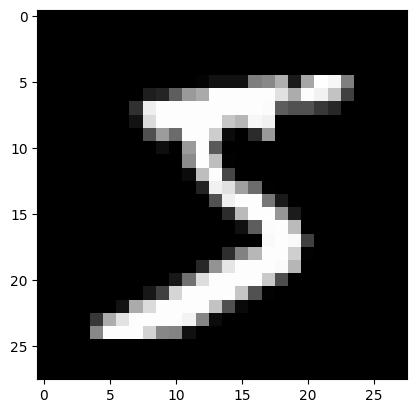

In [9]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].cpu().permute(1, 2, 0), cmap="gray")

In [4]:
X_train[0].permute(1, 2, 0).shape

torch.Size([28, 28, 1])

In [ ]:
import torch

import torch.nn as nn

# Training loop
import torch.optim as optim

class ConvolutionBlockWithChannelAndSpatialAttention(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3), **kwargs):
        super().__init__()
        # conv: input -> (B, in_channels, H, W) ; output -> (B, out_channels, H_out, W_out)
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=1, padding=0, **kwargs)  # -> (B, out_channels, H_out, W_out)
        self.bnorm = nn.BatchNorm2d(out_channels)  # -> (B, out_channels, H_out, W_out)
        self.act = nn.SiLU()  # -> (B, out_channels, H_out, W_out)
        
        # adaptive_pool: (B, out_channels, H_out, W_out) -> (B, out_channels, 1, 1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))  # -> (B, out_channels, 1, 1)
        # channel attention operates on (B, out_channels) vectors
        self.channel_attention = nn.Sequential(
            nn.Linear(out_channels, out_channels // 4),  # -> (B, out_channels//4)
            nn.SiLU(),
            nn.Linear(out_channels // 4, out_channels),  # -> (B, out_channels)
            nn.Sigmoid()  # -> (B, out_channels) (values in [0,1])
        )
        # spatial_attention: (B, out_channels, H_out, W_out) -> (B, 1, H_s, W_s)
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(out_channels, 1, kernel_size=7, padding=3),  # -> (B,1,H_s,W_s)
            nn.Sigmoid()  # -> (B,1,H_s,W_s) (values in [0,1])
        )
        
    def forward(self, x):
        # normalize input shapes to (B, C, H, W)
        if x.dim() == 3:
            x = x.unsqueeze(0)  # (C, H, W) -> (1, C, H, W)
        if x.dim() == 2:
            x = x.unsqueeze(0).unsqueeze(0)  # (H, W) -> (1,1,H,W)
        # conv / batchnorm / act
        x = self.conv(x)  # -> (B, out_channels, H_out, W_out)
        x = self.bnorm(x)  # -> (B, out_channels, H_out, W_out)
        x = self.act(x)  # -> (B, out_channels, H_out, W_out)
        
        # Channel attention
        channel_weights = self.adaptive_pool(x)  # -> (B, out_channels, 1, 1)
        channel_weights = channel_weights.view(channel_weights.size(0), -1)  # -> (B, out_channels)
        channel_weights = self.channel_attention(channel_weights)  # -> (B, out_channels)
        channel_weights = channel_weights.view(channel_weights.size(0), channel_weights.size(1), 1, 1)  # -> (B, out_channels,1,1)
        x = x * channel_weights  # broadcast multiply -> (B, out_channels, H_out, W_out)
        
        # Spatial attention
        spatial_weights = self.spatial_attention(x)  # -> (B,1,H_s,W_s)
        # spatial_weights must have H_s == H_out and W_s == W_out to broadcast correctly
        x = x * spatial_weights  # broadcast multiply -> (B, out_channels, H_out, W_out)
        
        return x  # keep spatial dims for next conv -> (B, out_channels, H_out, W_out)

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.blocks = nn.ModuleList([
            ConvolutionBlockWithChannelAndSpatialAttention(1, 8, kernel_size=(1, 1)),  # block output: (B,8,H,W)
            ConvolutionBlockWithChannelAndSpatialAttention(8, 64, kernel_size=(1, 1)),  # block output: (B,64,H,W)
            # ConvolutionBlockWithChannelAndSpatialAttention(16, 32, kernel_size=(1, 1))
        ])
        # infer flattened size using a dummy input
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)  # -> (1,1,28,28)
            out = dummy
            for b in self.blocks:
                out = b(out)  # -> (1, out_channels, H_out, W_out)
            flat_dim = out.view(1, -1).size(1)  # -> flatten to (1, flat_dim), take flat_dim
        self.fc = nn.Linear(flat_dim, 10)  # -> maps (B, flat_dim) to (B,10)
        
    def forward(self, x):
        for block in self.blocks:
            x = block(x)  # -> (B, out_channels, H, W) updated each block
        x = x.view(x.size(0), -1)  # -> (B, flat_dim)
        out = self.fc(x)  # -> (B, 10)
        return out
    
model = CNNModel().to(device)  # model parameters moved to device


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
batch_size = 64
num_samples = X_train.size(0)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for i in range(0, num_samples, batch_size):
        X_batch = X_train[i : i + batch_size]
        y_batch = y_train[i : i + batch_size]

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # Clear gradients

        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / num_samples
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/5, Loss: 0.2382
Epoch 2/5, Loss: 0.0969
Epoch 3/5, Loss: 0.0664
Epoch 4/5, Loss: 0.0482
Epoch 5/5, Loss: 0.0342


In [27]:

model.eval()
with torch.no_grad():
    val = model(X_test)
    
    # count correct predictions
    _, predicted = torch.max(val, 1)
    correct = (predicted == y_test).sum().item()
    total = y_test.size(0)
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9716


In [6]:
X_train[0].shape

torch.Size([1, 28, 28])

Original shape: 28x28
Resized shape: 32x32


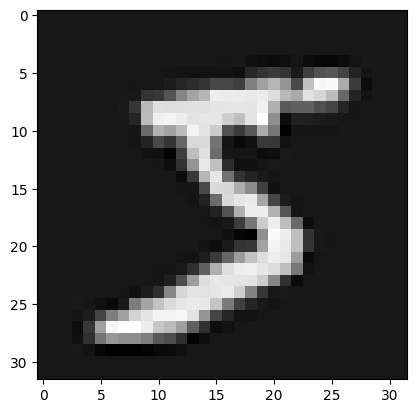

In [21]:
import torch
import torch.nn.functional as F
import math

# Sample input tensor (e.g., a batch of 1 image, 3 channels, 384x500 dimensions)
input_tensor = X_train[0].reshape(1, 1, 28, 28)  # Reshape to (B, C, H, W) for testing
_, _, h, w = input_tensor.shape

# 1. Calculate nearest powers of 2 for height and width
target_h = 2 ** round(math.log2(h))
target_w = 2 ** round(math.log2(w))

# 2. Interpolate the tensor
# mode='bilinear' is commonly used; 'nearest' or 'bicubic' are also available
output_tensor = F.interpolate(
    input_tensor, size=(target_h, target_w), mode="bicubic", align_corners=False
)

print(f"Original shape: {h}x{w}")
print(f"Resized shape: {target_h}x{target_w}")


plt.imshow(output_tensor[0].cpu().permute(1, 2, 0), cmap="gray")